<a href="https://colab.research.google.com/github/antoine-jossien/2026_Intro_Python/blob/main/live/part-I/1.3-numpy-exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> Notebook-friendly copy of `part-I/1.3-numpy-exercises.ipynb`, generated by `tools/make_live.py`. Edit the book notebook, not this file.

In [ ]:
# --- environment setup (generated, not part of the lesson) ---
# Colab and Kaggle do not ship every package this notebook imports.
# This is a no-op in an environment that is already set up.
import importlib.util
import subprocess
import sys

for module, package in {"gsw": "gsw", "pooch": "pooch"}.items():
    if importlib.util.find_spec(module) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

# Exercises

**ℹ️ How to use these exercises**

Attempt each from scratch in the empty code cell. Import numpy as `np`, and encode units in your variable names.

## Exercise 1: Create and inspect

Build the following 3×4 field of temperatures (°C) as a numpy array:

`5.2 4.8 6.1 3.9 1.3 0.5 -0.8 -1.2 -2.6 -3.1 -1.9 0.2`

Print its `shape`, `ndim`, and `dtype`, and its overall mean rounded to two decimals.
Then create, and print, three arrays of the same shape without typing the shape out by hand:
all ones, a uniform reference field of 15.0 °C, and random values in [0, 1).

In [ ]:
# Your solution here

import numpy as np
temp_celsius = np.array([[5.2, 4.8, 6.1, 3.9], [1.3, 0.5, -0.8, -1.2], [-2.6, -3.1, -1.9, 0.2]])

print(temp_celsius)
print(temp_celsius.shape)
print(temp_celsius.ndim)
print(temp_celsius.dtype)



[[ 5.2  4.8  6.1  3.9]
 [ 1.3  0.5 -0.8 -1.2]
 [-2.6 -3.1 -1.9  0.2]]
(3, 4)
2
float64


## Exercise 2: Index and slice

Given

```python
a = np.array([[1.0, 2.0, 3.0, 4.0],
              [5.0, 6.0, 7.0, 8.0],
              [9.0, 10.0, 11.0, 12.0]])
```

print the last row, the first column, and the 2×2 sub-block formed by the first two rows and the last two columns.

Finally, take a slice of the first row, change its first element to `99.0`, and print the original array. Then repeat using `.copy()`. Explain the difference in a comment.

In [ ]:
# Your solution here
a = np.array([[1.0, 2.0, 3.0, 4.0],
              [5.0, 6.0, 7.0, 8.0],
              [9.0, 10.0, 11.0, 12.0]])

print(a)

print(a[-1,:])
print(a[:,0])
print(a[:2, -2:])

row_view = a[0, :]   # first row (basic slicing -> view)
row_view[0] = 99.0
print(a)             # a[0, 0] is now 99.0: the original was modified

# --- 2) Slice WITH .copy(): independent array ---
a = np.array([[1.0, 2.0, 3.0, 4.0],
              [5.0, 6.0, 7.0, 8.0],
              [9.0, 10.0, 11.0, 12.0]])   # reset the original

row_copy = a[0, :].copy()
row_copy[0] = 99.0
print(a)

[[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]]
[ 9. 10. 11. 12.]
[1. 5. 9.]
[[3. 4.]
 [7. 8.]]
[[99.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]]
[[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]]


## Exercise 3: Masking and np.where

Given

```python
temp_celsius = np.array([[-1.0, 12.0,  3.0],
                         [ 8.0, -2.0, 15.0],
                         [ 4.0,  0.5, 11.0]])
```

print the values that exceed 10 °C, their mean, and the percentage of the field they make up.
Then build a clipped field in which every value below 0 °C is set to 0, using `np.where`.

In [ ]:
# Your solution here

temp_celsius = np.array([[-1.0, 12.0,  3.0],
                         [ 8.0, -2.0, 15.0],
                         [ 4.0,  0.5, 11.0]])

print(temp_celsius[temp_celsius > 10])
print(temp_celsius[temp_celsius > 10].mean())
print(temp_celsius[temp_celsius > 10].size / temp_celsius.size)

category = np.where(temp_celsius < 0, 0, temp_celsius )
print("category:", category)



[12. 15. 11.]
12.666666666666666
0.3333333333333333
category: [[ 0.  12.   3. ]
 [ 8.   0.  15. ]
 [ 4.   0.5 11. ]]


## Exercise 4: Broadcasting and grids

Given the field below, add a per-column offset (length 4) to every row, and separately add a per-row offset (length 3) to every column.

```python
field = np.array([[1.0, 2.0, 3.0, 4.0],
                  [5.0, 6.0, 7.0, 8.0],
                  [9.0, 10.0, 11.0, 12.0]])
col_offset = np.array([0.0, 1.0, 2.0, 3.0])
row_offset = np.array([10.0, 20.0, 30.0])
```

Then build a grid of 4 evenly spaced longitudes from 6 to 9 °E and 3 evenly spaced latitudes
from 46 to 47 °N, so that it has the same shape as `field`. On that grid, compute a synthetic temperature
field that is 15.0 °C at (6 °E, 46 °N), cools by 0.6 °C per degree of latitude northward, and warms
by 0.2 °C per degree of longitude eastward. Compute it twice, once from the 2D arrays that
`np.meshgrid` returns and once by broadcasting the 1D latitudes and longitudes directly, and
confirm with `np.allclose` that the two agree.

In [ ]:
# Your solution here

field = np.array([[1.0, 2.0, 3.0, 4.0],
                  [5.0, 6.0, 7.0, 8.0],
                  [9.0, 10.0, 11.0, 12.0]])
col_offset = np.array([0.0, 1.0, 2.0, 3.0])
row_offset = np.array([10.0, 20.0, 30.0])

#print(field + col_offset)
#print(field + row_offset[:, np.newaxis])
lon = np.linspace(6, 9.0, 4)
lat = np.linspace(46, 47, 3)


lon2D,lat2D = np.meshgrid(lon, lat)
print(lon2D)
print(lat2D)

Temp_mesh = 15 - 0.6*(lat2D - 46) + 0.2*(lon2D - 6)
print("temp_mesh:", Temp_mesh)

print("latnew:", lat[:, np.newaxis])
print("lonnew:", lon[np.newaxis, :])

temp_bro = 15 - 0.6*(lat[:, np.newaxis] - 46) + 0.2*(lon[np.newaxis, :] - 6)
print("temp_bro:", temp_bro)


print(np.allclose(Temp_mesh, temp_bro))


[[6. 7. 8. 9.]
 [6. 7. 8. 9.]
 [6. 7. 8. 9.]]
[[46.  46.  46.  46. ]
 [46.5 46.5 46.5 46.5]
 [47.  47.  47.  47. ]]
temp_mesh: [[15.  15.2 15.4 15.6]
 [14.7 14.9 15.1 15.3]
 [14.4 14.6 14.8 15. ]]
latnew: [[46. ]
 [46.5]
 [47. ]]
lonnew: [[6. 7. 8. 9.]]
temp_bro: [[15.  15.2 15.4 15.6]
 [14.7 14.9 15.1 15.3]
 [14.4 14.6 14.8 15. ]]
True


## Exercise 5: Axis reductions

Given seasonal mean temperatures at three stations, one row per station and one column per season
(winter, spring, summer, autumn):

```python
seasonal_celsius = np.array([[ 2.1,  9.8, 18.4, 10.2],
                             [-1.5,  7.2, 16.9,  8.0],
                             [ 4.0, 11.5, 20.3, 12.6]])
```

print the annual mean at each station and the index of each station's warmest season. Then find the
coldest value in each season twice, once with the method and once with the numpy function, and
confirm they agree.

Finally, given four days of rainfall at two stations, one row per station,

```python
rain_mm = np.array([[0.0, 6.2, 1.1, 0.0],
                    [2.4, 0.0, 0.0, 8.3]])
```

use `cumsum` along the right axis to get the rain to date. Print the index of the station that was
wetter after the second day and the index of the station that was wetter after all four. Are they
the same station?

In [26]:
# Your solution here

import numpy as np

seasonal_celsius = np.array([[ 2.1,  9.8, 18.4, 10.2],
                             [-1.5,  7.2, 16.9,  8.0],
                             [ 4.0, 11.5, 20.3, 12.6]])

# --- Partie 1 : stations (lignes) x saisons (colonnes) ---
print(seasonal_celsius.mean(axis=1))     # moyenne annuelle par station
print(seasonal_celsius.argmax(axis=1))   # indice de la saison la plus chaude par station

a1 = seasonal_celsius.min(axis=0)        # méthode
a2 = np.min(seasonal_celsius, axis=0)    # fonction numpy
print(a1, a2)
print(np.allclose(a1, a2))               # True

# --- Partie 2 : pluie ---
rain_mm = np.array([[0.0, 6.2, 1.1, 0.0],
                    [2.4, 0.0, 0.0, 8.3]])

# Le temps est sur les colonnes, donc on cumule le long des colonnes : axis=1
rain_to_date = rain_mm.cumsum(axis=1)
print(rain_to_date)

wetter_day2 = rain_to_date[:, 1].argmax()    # colonne 1 = après le 2e jour
wetter_day4 = rain_to_date[:, -1].argmax()   # dernière colonne = après les 4 jours
print(wetter_day2, wetter_day4)
print(wetter_day2 == wetter_day4)

[10.125  7.65  12.1  ]
[2 2 2]
[-1.5  7.2 16.9  8. ] [-1.5  7.2 16.9  8. ]
True
[[ 0.   6.2  7.3  7.3]
 [ 2.4  2.4  2.4 10.7]]
0 1
False


## Exercise 6: Missing data and interpolation

Given hourly air temperatures with a gap of two readings,

```python
temp_celsius = np.array([12.0, 13.5, np.nan, np.nan, 18.0, 18.5])
```

fill the gap by linear interpolation against the integer index. Then print the NaN-aware mean of the
original series and the ordinary mean of the filled one. The two differ; say in a comment why.

In [27]:
# Your solution here

import numpy as np

temp_celsius = np.array([12.0, 13.5, np.nan, np.nan, 18.0, 18.5])

# np.interp(x_à_calculer, x_connus, y_connus)
x = np.arange(temp_celsius.size)       # indices 0 à 5
valid = ~np.isnan(temp_celsius)        # True là où la mesure existe

filled = np.interp(x, x[valid], temp_celsius[valid])
print(filled)

print(np.nanmean(temp_celsius))   # moyenne de la série originale, en ignorant les NaN
print(filled.mean())              # moyenne ordinaire de la série comblée

# Les deux diffèrent car np.nanmean ne moyenne que les 4 valeurs mesurées
# (12.0, 13.5, 18.0, 18.5), alors que filled.mean() moyenne 6 valeurs, dont
# les 2 valeurs interpolées (15.0 et 16.5). Ces valeurs estimées sont plus
# hautes que la moyenne des mesures (15.5), donc elles tirent la moyenne vers le haut.

[12.  13.5 15.  16.5 18.  18.5]
15.5
15.583333333333334


## Exercise 7: Avoid the dtype trap

An assistant wrote this function to compute each cell's share of the total rainfall in an integer
field of rain-gauge readings:

```python
def rain_share(rain_mm):
    share = np.zeros_like(rain_mm)
    share[:] = rain_mm / rain_mm.sum()
    return share

rain_mm = np.array([[0, 2, 5], [1, 0, 8], [3, 4, 2]])
```

Call it and print the result. Explain in a comment why every share is 0, then fix the function
twice: once keeping the preallocation but passing `dtype=float` to `np.zeros_like`, and once
without preallocating at all. Confirm that each fixed version returns a float array whose shares
sum to 1.

In [28]:
# Your solution here

import numpy as np

def rain_share(rain_mm):
    share = np.zeros_like(rain_mm)
    share[:] = rain_mm / rain_mm.sum()
    return share

rain_mm = np.array([[0, 2, 5], [1, 0, 8], [3, 4, 2]])

print(rain_share(rain_mm))

# Pourquoi tout vaut 0 : rain_mm est un tableau d'entiers (int64), donc
# np.zeros_like(rain_mm) crée aussi un tableau d'entiers (il copie le dtype
# de l'entrée). La division rain_mm / rain_mm.sum() donne bien des flottants
# (entre 0 et 1), mais quand on les assigne dans `share`, numpy les convertit
# en entiers en les tronquant vers 0 : 0.0, 0.04, 0.17... deviennent tous 0.
# Aucune erreur n'est levée, les résultats sont silencieusement faux.

# --- Correction 1 : on garde la préallocation, mais avec dtype=float ---
def rain_share_v1(rain_mm):
    share = np.zeros_like(rain_mm, dtype=float)   # tableau de flottants
    share[:] = rain_mm / rain_mm.sum()
    return share

# --- Correction 2 : pas de préallocation, numpy choisit le bon type ---
def rain_share_v2(rain_mm):
    return rain_mm / rain_mm.sum()

s1 = rain_share_v1(rain_mm)
s2 = rain_share_v2(rain_mm)

print(s1)
print(s2)
print(s1.dtype, s2.dtype)                  # float64 float64
print(s1.sum(), s2.sum())                  # 1.0 1.0
print(np.isclose(s1.sum(), 1.0), np.isclose(s2.sum(), 1.0))   # True True
print(np.allclose(s1, s2))                 # True : les deux versions concordent

[[0 0 0]
 [0 0 0]
 [0 0 0]]
[[0.   0.08 0.2 ]
 [0.04 0.   0.32]
 [0.12 0.16 0.08]]
[[0.   0.08 0.2 ]
 [0.04 0.   0.32]
 [0.12 0.16 0.08]]
float64 float64
1.0000000000000002 1.0000000000000002
True True
True


## Exercise 8: Reshape and stack

1. Create the integers 0 to 11 as a 1D array, then reshape it into a 3×4 array and print both
   shapes.
2. Reshape the same data into a 4×3 array. Print it and say in a comment why the numbers appear
   in a different arrangement.
3. Use `reshape(-1)` to flatten your 3×4 array back to 1D, and confirm the shape.
4. Stack the 3×4 array on top of a row of zeros with `np.vstack`, and print the resulting shape.

In [29]:
# Your solution here

import numpy as np

# 1) entiers de 0 à 11, puis reshape en 3x4
a = np.arange(12)
a34 = a.reshape(3, 4)
print(a.shape, a34.shape)    # (12,) (3, 4)
print(a34)

# 2) mêmes données en 4x3
a43 = a.reshape(4, 3)
print(a43)
# Les nombres semblent rangés autrement parce que reshape ne change pas l'ordre
# des données : numpy lit toujours 0, 1, 2, ..., 11 dans cet ordre et remplit
# le nouveau tableau ligne par ligne. Avec 4 colonnes, une ligne prend 4 valeurs
# (0-3, 4-7, 8-11). Avec 3 colonnes, elle n'en prend que 3 (0-2, 3-5, 6-8, 9-11).
# Seul le découpage en lignes change, pas la suite des valeurs.

# 3) aplatir le 3x4 avec reshape(-1)
flat = a34.reshape(-1)       # -1 : numpy calcule la longueur manquante (12)
print(flat.shape)            # (12,)

# 4) empiler le 3x4 au-dessus d'une ligne de zéros
zeros_row = np.zeros(4)      # 4 éléments, comme le nombre de colonnes de a34
stacked = np.vstack([a34, zeros_row])
print(stacked.shape)         # (4, 4)
print(stacked)

(12,) (3, 4)
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]
(12,)
(4, 4)
[[ 0.  1.  2.  3.]
 [ 4.  5.  6.  7.]
 [ 8.  9. 10. 11.]
 [ 0.  0.  0.  0.]]


## Exercise 9: Ocean float profiles

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/argo-float-cycle.png" alt="A diagram of one Argo float cycle, numbered one to seven, from deployment through drift, dive, ascent and satellite transmission" width="100%">

<em>One cycle of an Argo float: deployment, descent to a drifting depth of about 1000 m, ten days of
drift, a dive to the profiling depth, then the ascent during which the measurements are taken, and
transmission to satellite at the surface before the next cycle begins. The panel on the right shows
what one ascent produces — the temperature and salinity profiles you are about to work with.
Illustration &copy; Thomas Haessig, from
<a href="https://www.euro-argo.eu/Outreach/Educational-material/Discover-Argo-floats-for-kids/How-do-the-Argo-floats-fulfill-their-mission-in-the-Ocean">Euro-Argo ERIC's educational material</a>.</em>


[Argo](https://argo.ucsd.edu/) floats are autonomous instruments that drift with ocean currents,
periodically diving and surfacing while recording temperature, salinity, and pressure. Each dive
produces one *profile*: a set of measurements at many depth *levels*, with a single latitude,
longitude, and date attached.

This exercise uses real Argo data. Steps 1 to 8 use only what 1.1 to 1.3 cover: loading
arrays, inspecting shapes, rebuilding an axis, vectorised arithmetic, reductions along an axis,
boolean masks, and NaN-aware statistics. Steps 9 to 11 then plot what you computed.

**ℹ️ Beyond this subchapter**

Steps 9 to 11 use `matplotlib`, which gets its own treatment in 1.4. Import it once with
`import matplotlib.pyplot as plt`; after that you need only the functions below, and each is
named again where it is wanted:

- `plt.figure()` — start a new, empty figure; without it, every plot in a cell lands on the
  same axes
- [`plt.plot`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) — a line, or
  one line per column when handed a 2D array
- [`plt.errorbar`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.errorbar.html) — a
  line with error bars
- [`plt.scatter`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) — points
- `plt.xlabel`, `plt.ylabel`, `plt.title` — each takes a string
- `plt.show()` — draw the current figure

An array of numbers with no picture attached is hard to sanity-check, which is why these three
steps sit here rather than waiting for 1.4: the profiles are the fastest way to see whether Steps 4
to 6 produced something physical.

In [30]:
# Pre-supplied: download and unzip the Argo data files.
import pooch

files = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/argo_float_data.zip",
    known_hash="sha256:dd913ba3450241bcd5d5697187ea68d398bdd7fd563a04cc74386834749c25f5",
    processor=pooch.Unzip(),
    path=pooch.os_cache("mlees"),
)
for f in sorted(files):
    print(f)

Unzipping contents of '/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip' to '/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip'


/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/P.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/S.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/T.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/date.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/lat.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/levels.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/lon.npy


**Step 1.** Load each `.npy` file into a numpy array with `np.load`. Name them `T` (temperature,
°C), `S` (practical salinity, unitless), `P` (pressure, dbar), `date`, `lat`, `lon`, and `level` (depth level).

Read the filenames printed above to work out which file is which.

In [32]:
# Your solution here
import numpy as np
from pathlib import Path

folder = Path(files[0]).parent      # le dossier qui contient tous les .npy

T     = np.load(folder / "T.npy")
S     = np.load(folder / "S.npy")
P     = np.load(folder / "P.npy")
date  = np.load(folder / "date.npy")
lat   = np.load(folder / "lat.npy")
lon   = np.load(folder / "lon.npy")
level = np.load(folder / "levels.npy")   # attention : le fichier s'appelle "levels.npy"


for name, arr in [("T", T), ("S", S), ("P", P), ("date", date),
                  ("lat", lat), ("lon", lon), ("level", level)]:
    print(name, arr.shape, arr.dtype)
# Hint: every file sits in the same folder, Path(files[0]).parent (Path comes from pathlib)
# Hint: join a filename onto that folder with /, as in Path("_files") / "station_daily.csv"
# Hint: np.load(path) returns the array stored in a .npy file

T (78, 75) float64
S (78, 75) float64
P (78, 75) float64
date (75,) datetime64[ns]
lat (75,) float64
lon (75,) float64
level (78,) int64


**Step 2.** Print the `shape` of every array you loaded. Then answer in a comment: which
dimension do `T`, `S`, and `P` share with `level`, and which do they share with `lat`, `lon`,
and `date`?

In [33]:
# Your solution here
for name, arr in [("T", T), ("S", S), ("P", P), ("date", date),
                  ("lat", lat), ("lon", lon), ("level", level)]:
    print(name, arr.shape)

# T, S and P have shape (78, 75). Their first dimension (axis 0, 78) is the
# one they share with `level`: each row is one depth level. Their second
# dimension (axis 1, 75) is the one they share with `lat`, `lon` and `date`:
# each column is one profile (one dive of the float), and each profile has a
# single latitude, longitude and date attached.
# Hint: the profile arrays are two-dimensional; the coordinate arrays are one-dimensional
# Hint: a 2D array's shape tells you the length of each axis — match those against the 1D shapes

T (78, 75)
S (78, 75)
P (78, 75)
date (75,)
lat (75,)
lon (75,)
level (78,)


**Step 3.** The `level` array is a regular sequence. Recreate it twice — once with `np.arange`
and once with `np.linspace` — and confirm each matches the original using `np.allclose`.

Read `level[0]`, `level[-1]`, and `level.size` first to work out the arguments.

In [34]:
# Your solution here

print(level[0], level[-1], level.size)

level_arange = np.arange(level[0], level[-1] + 1)   # pas = 1 par défaut
print(np.allclose(level_arange, level))              # True
level_linspace = np.linspace(level[0], level[-1], level.size)
print(np.allclose(level_linspace, level))            # True
# Hint: np.arange(start, stop, step) excludes the stop value
# Hint: np.linspace(start, stop, num) includes both ends
# Hint: np.allclose(a, b) returns True when every pair of elements is close enough

0 77 78
True
True


**Step 4.** Compute the density of seawater relative to pure water, in kg m⁻³:

$$\rho - \rho_{\text{pure water}} = a\,S + b\,\Theta + c\,\Theta^{2}$$

where $S$ is salinity and $\Theta$ is the *conservative* temperature, computed from
temperature, salinity, and pressure by the `gsw` library. The constants are

```python
a = 7.718e-1
b = -8.44e-2
c = -4.561e-3
```

The cell below imports the function. Compute `conservative_temp` and `relative_density`, print
the shape of your result, and check it matches `T`.

Both `CT_from_t` and the formula expect *absolute* salinity, in g/kg, while Argo reports
*practical* salinity, which has no unit. Absolute salinity is about 0.5 % larger; for these
profiles, using practical salinity in its place lowers every relative density by about
0.13 kg m⁻³, which is small enough to ignore here. `gsw.SA_from_SP` does the exact conversion
when it matters.

Source: Roquet et al. (2015), *J. Phys. Oceanogr.* 45, 2564–2579, and the
[TEOS-10 GSW toolbox](https://www.teos-10.org/).

In [35]:
# Pre-supplied: the conservative-temperature function from the gsw library
from gsw import CT_from_t

In [36]:
# Your solution here

import numpy as np
from gsw import CT_from_t

# constants of the density formula
a = 7.718e-1
b = -8.44e-2
c = -4.561e-3

# conservative temperature (argument order: salinity, temperature, pressure)
conservative_temp = CT_from_t(S, T, P)

# relative density: rho - rho_pure_water = a*S + b*CT + c*CT**2
relative_density = a * S + b * conservative_temp + c * conservative_temp**2

print(relative_density.shape)
print(relative_density.shape == T.shape)   # True
# Hint: CT_from_t(SA, t, p) takes salinity, temperature, and pressure — in that order
# Hint: the whole formula is one vectorised expression; no loop is needed
# Hint: Theta**2 squares every element

(78, 75)
True


**Step 5.** Compute the mean and the standard deviation of `T`, `S`, `P`, and
`relative_density` **at each depth**, averaging across all the profiles.

Check your result has the same shape as `level` — if it does not, you reduced along the wrong
axis.

In [37]:
# Your solution here
# mean and standard deviation at each depth, across all profiles
# (NaN-aware, because the data contain missing values)
T_mean = np.nanmean(T, axis=1)
T_std = np.nanstd(T, axis=1)

S_mean = np.nanmean(S, axis=1)
S_std = np.nanstd(S, axis=1)

P_mean = np.nanmean(P, axis=1)
P_std = np.nanstd(P, axis=1)

rho_mean = np.nanmean(relative_density, axis=1)
rho_std = np.nanstd(relative_density, axis=1)

# check: one value per depth level, so the shape must match `level`
print(T_mean.shape, level.shape)
print(T_mean.shape == level.shape)   # True
print(S_mean.shape, P_mean.shape, rho_mean.shape)
# Hint: pick the axis that runs across profiles, not across depths
# Hint: mean_T.shape should equal level.shape

(78,) (78,)
True
(78,) (78,) (78,)


**Step 6.** Look at the mean you just computed. Many entries are `nan`, because Argo profiles
contain missing values and an ordinary mean propagates them.

1. Count how many values in `T` are missing, using `np.isnan` and a sum over the boolean mask.
2. Express that as a percentage of all values in `T`.
3. Recompute the mean and standard deviation with `np.nanmean` and `np.nanstd`, and confirm no
   `nan` remains.

In [38]:
# Your solution here
# 1) number of missing values in T
missing_mask = np.isnan(T)               # True where a value is missing
n_missing = missing_mask.sum()           # True counts as 1
print("missing values:", n_missing)

# 2) as a percentage of all values
pct_missing = n_missing / T.size * 100
print(f"missing: {pct_missing:.2f} %")

# ordinary mean and std (for comparison): NaN propagates
T_mean_plain = T.mean(axis=1)
T_std_plain = T.std(axis=1)
print("nan in ordinary mean:", np.isnan(T_mean_plain).sum(), "of", T_mean_plain.size)

# 3) NaN-aware versions
T_mean = np.nanmean(T, axis=1)
T_std = np.nanstd(T, axis=1)
print("nan in nanmean:", np.isnan(T_mean).sum())   # 0
print("nan in nanstd: ", np.isnan(T_std).sum())    # 0
# Hint: np.isnan(T) gives a boolean array; True counts as 1 when summed
# Hint: T.size is the total number of elements
# Hint: np.isnan(result).sum() counts the nan that survived; it should be 0

missing values: 101
missing: 1.73 %
nan in ordinary mean: 55 of 78
nan in nanmean: 0
nan in nanstd:  0


**Step 7.** Using `np.where`, build an array that labels each depth `"warm"` where the mean
temperature there is above 10 °C and `"cold"` otherwise. Print the first ten labels alongside
the first ten depths.

Then, using a boolean mask, print the depths at which the mean temperature is below 5 °C.

In [39]:
# Your solution here
# T_mean: mean temperature at each depth level, shape (78,)
T_mean = np.nanmean(T, axis=1)

# label each depth: "warm" where the mean is above 10 °C, "cold" otherwise
label = np.where(T_mean > 10.0, "warm", "cold")

# first ten labels alongside the first ten depths
print(label[:10])
print(level[:10])
for lev, lab in zip(level[:10], label[:10]):
    print(lev, lab)

# boolean mask: depths where the mean temperature is below 5 °C
below5 = T_mean < 5.0
print(level[below5])
# Hint: np.where(condition, value_if_true, value_if_false) works element-wise
# Hint: level[mask] selects the depths where the mask is True

['warm' 'warm' 'warm' 'warm' 'warm' 'warm' 'warm' 'warm' 'warm' 'warm']
[0 1 2 3 4 5 6 7 8 9]
0 warm
1 warm
2 warm
3 warm
4 warm
5 warm
6 warm
7 warm
8 warm
9 warm
[63 64 65 66 67 68 69 70 71 72 73 74 75 76 77]


**Step 8.** Assemble a summary array with `np.vstack`: one row of depths, one of mean
temperature, one of mean salinity, and one of mean relative density — four rows in total.

Print its shape, save it to `_files/argo_summary.npy`, load it back, and confirm with `np.allclose`
that the round trip changed nothing.

In [40]:
# Your solution here

from pathlib import Path

# means per depth level (each has shape (78,))
T_mean = np.nanmean(T, axis=1)
S_mean = np.nanmean(S, axis=1)
rho_mean = np.nanmean(relative_density, axis=1)

# stack four rows: depths, mean T, mean S, mean relative density
summary = np.vstack([level, T_mean, S_mean, rho_mean])
print(summary.shape)                     # (4, 78)

# save, reload, compare
Path("_files").mkdir(exist_ok=True)      # create the folder if it does not exist
np.save("_files/argo_summary.npy", summary)

reloaded = np.load("_files/argo_summary.npy")
print(reloaded.shape, reloaded.dtype)
print(np.allclose(summary, reloaded))    # True
# Hint: np.vstack takes a list of 1D arrays and stacks them as rows
# Hint: your summary should have shape (4, n_levels)
# Hint: _files/ may not exist yet; create it first with Path("_files").mkdir(exist_ok=True)

(4, 78)
(4, 78) float64
True


**Step 9.** Plot each of `T`, `S`, `P` and `relative_density` against depth — four figures, one
per variable.

Each array is `(level, profile)`, so handing the whole array to `plt.plot` draws one line per
profile. Put the variable on the *x*-axis and `level` on the *y*-axis, which is the oceanographic
convention: depth runs down the page, and a profile is read the way the float measured it.

It will look messy, because 75 profiles are drawn on top of each other.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.3-target-argo-profiles.png" alt="Many overlapping salinity profiles plotted against depth level, forming a dense band that shifts towards fresher water with depth" width="500">

<em>The salinity panel, as a check on yours. Label the axes and give each figure a title.</em>

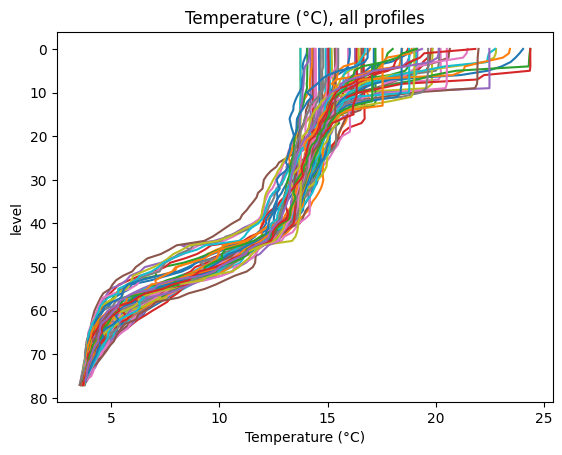

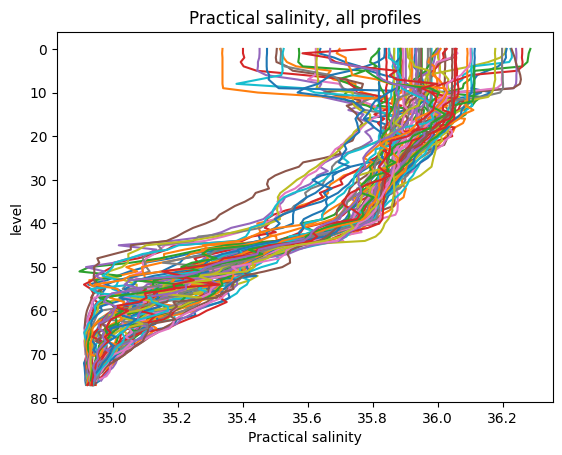

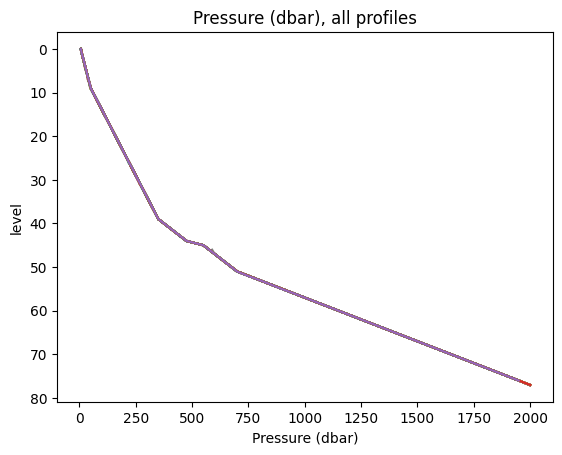

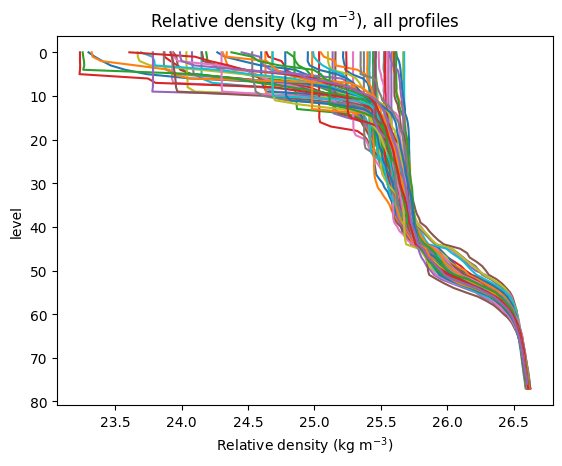

In [41]:
# Your solution here
import matplotlib.pyplot as plt

variables = [
    ("Temperature (°C)", T),
    ("Practical salinity", S),
    ("Pressure (dbar)", P),
    ("Relative density (kg m$^{-3}$)", relative_density),
]

for label, data in variables:
    plt.figure()                    # new empty figure for each variable
    plt.plot(data, level)           # x = variable (78, 75), y = level (78,)
    plt.gca().invert_yaxis()        # level 0 (surface) at the top
    plt.xlabel(label)
    plt.ylabel("level")
    plt.title(label + ", all profiles")
    plt.show()
# Hint: plt.figure() before each variable's plot, plt.show() after it
# Hint: plt.plot(S, level) draws one line per column of S
# Hint: the semicolon at the end of a plt.plot call suppresses the list of line objects
# Hint: plt.xlabel, plt.ylabel and plt.title each take a string

**Step 10.** Now plot only the *mean* profile of each variable, with the standard deviation as
error bars.

Use the NaN-aware mean and standard deviation from Step 6, and draw them with `plt.errorbar`.
Because the variable is on the *x*-axis, the spread is a *horizontal* error bar — the keyword is
`xerr`, not `yerr`.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.3-target-argo-mean-profiles.png" alt="A single mean salinity profile against depth level with horizontal error bars at each level" width="500">

<em>The salinity panel again, reduced from 75 profiles to one line and its spread.</em>


In a comment, say what the width of the error bars tells you about how much the profiles disagree
near the surface compared with at depth.

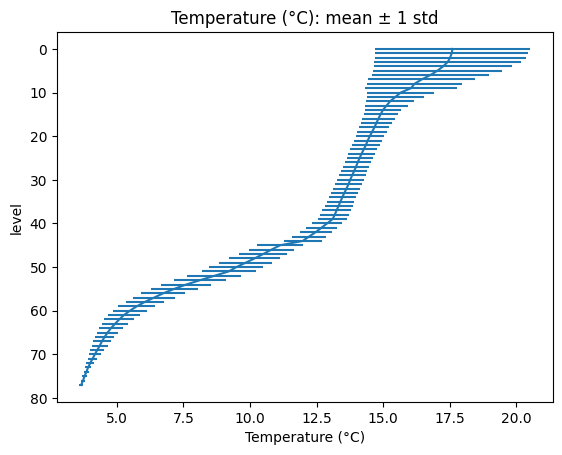

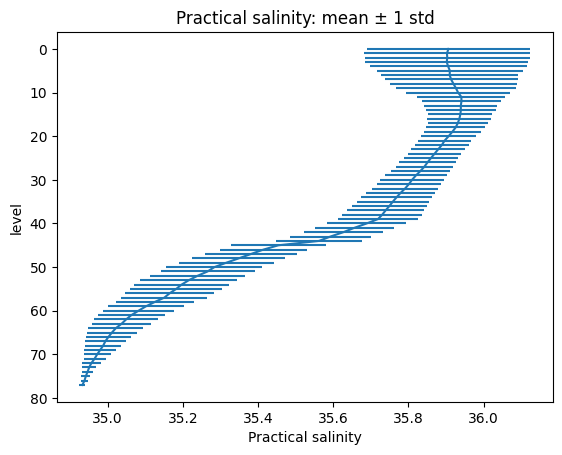

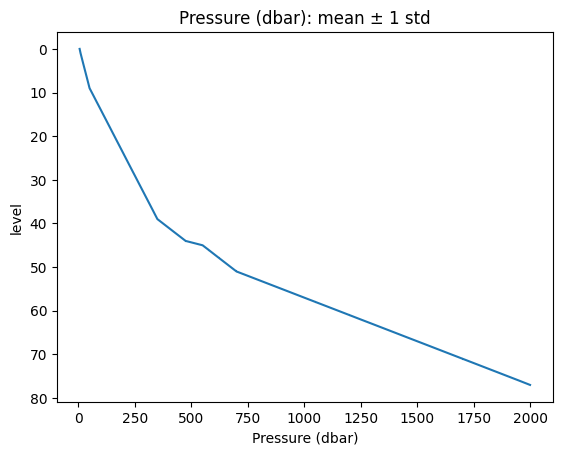

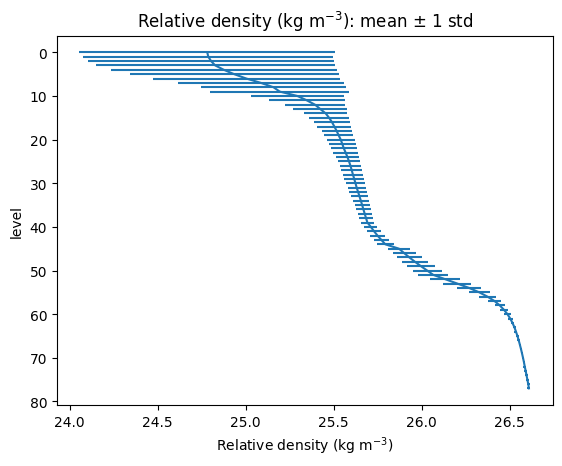

In [42]:
# Your solution here
# NaN-aware mean and std at each depth, across profiles (shape (78,) each)
means = {
    "Temperature (°C)":               (np.nanmean(T, axis=1),                np.nanstd(T, axis=1)),
    "Practical salinity":             (np.nanmean(S, axis=1),                np.nanstd(S, axis=1)),
    "Pressure (dbar)":                (np.nanmean(P, axis=1),                np.nanstd(P, axis=1)),
    "Relative density (kg m$^{-3}$)": (np.nanmean(relative_density, axis=1), np.nanstd(relative_density, axis=1)),
}

for label, (mean, std) in means.items():
    plt.figure()
    plt.errorbar(mean, level, xerr=std)    # horizontal error bars: variable is on x
    plt.gca().invert_yaxis()               # surface at the top
    plt.xlabel(label)
    plt.ylabel("level")
    plt.title(label + ": mean ± 1 std")
    plt.show()
# Hint: plt.errorbar(mean_S, level, xerr=std_S)
# Hint: use the nan-aware versions from Step 6, or every bar will be missing

**Step 11.** Scatter the profiles' longitudes against their latitudes.

One point per profile. Label both axes and give it a title, and set the marker size with `s=` so
the points are readable. Then print the first three entries of `date` and the last one.

In a comment, say what the dates and the shape of the cloud tell you about how this set of
profiles was collected, and by how many floats.

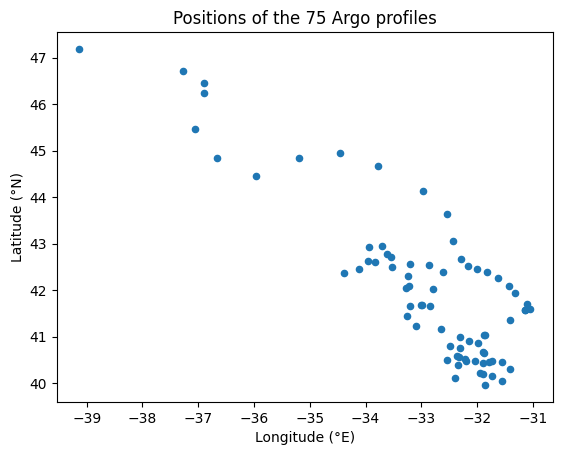

['2012-07-13T22:33:06.019200000' '2012-07-23T22:54:59.990400000'
 '2012-08-02T22:55:52.003200000']
2014-07-24T03:02:33.014400000


In [43]:
# Your solution here
plt.figure()
plt.scatter(lon, lat, s=20)
plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.title("Positions of the 75 Argo profiles")
plt.show()

print(date[:3])
print(date[-1])

# The dates are regularly spaced, about 10 days apart (from 2012-07-13 to
# 2014-07-24, about two years), which matches the Argo cycle of roughly ten
# days. The points form a single connected trail instead of several separate
# clusters: consecutive positions are close to each other and the trail drifts
# from the north-west (around 47 °N, 39 °W) towards the south-east (around
# 40 °N, 31 °W), then wanders in a small area. This is the trajectory of ONE
# float, which drifted with the ocean currents and surfaced every ~10 days.
# So the 75 "profiles" are repeated dives by a single float, not 75 floats.
# Hint: plt.scatter(lon, lat)
# Hint: lon and lat have one entry per profile, not per level
# Hint: look at the spacing between consecutive dates

**ℹ️ What you just did**

You loaded a real oceanographic dataset, worked out its structure from the array shapes alone,
rebuilt a coordinate axis and verified it, evaluated a published equation of state as one
vectorised expression over 5,850 measurements (78 depth levels by 75 profiles), reduced along the
right axis, counted the missing values and switched to NaN-aware statistics, and saved a derived
product.

None of the computation needed a loop over the data. In the next subchapter `xarray` attaches the
names (depth, profile, latitude) to the axes you have been tracking by hand, and `matplotlib` gets
its full treatment, including the line, error-bar and scatter plots you drew here.